# Build a NN from Scratch (MNIST)

# Install Dependencies

In [ ]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib

# Load and preprocess data

In [1]:
import tensorflow as tf
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

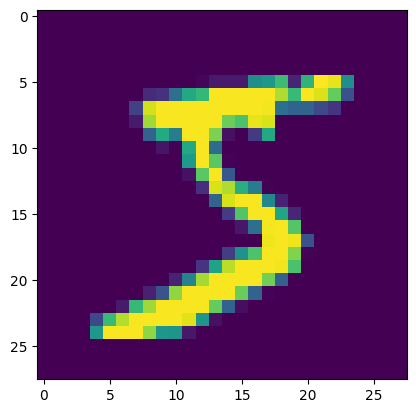

In [3]:
plt.imshow(x_train[0])

In [4]:
x_train = x_train.reshape(60000,784 * 1).T
y_train = y_train.reshape(y_train.shape[0],-1).T

# Set the Environment Matrices

In [5]:
def init_params(input_size, hidden_size1, hidden_size2, output_size):
    # Weights
    w1 = np.random.rand(hidden_size1, input_size) - 0.5
    w2 = np.random.rand(hidden_size2, hidden_size1) - 0.5
    w3 = np.random.rand(output_size, hidden_size2) - 0.5

    # Biases
    b1 = np.random.rand(hidden_size1, 1) - 0.5
    b2 = np.random.rand(hidden_size2, 1) - 0.5
    b3 = np.random.rand(output_size, 1) - 0.5

    return w3, b3, w2, b2, w1, b1

# Activation Functions

ReLU function:

                                                                    max(0,z)

In [6]:
def ReLU(z):
    return np.maximum(0,z)

def der_ReLU(z):
    return z > 0

sigmoid function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [7]:
def sigmoid(z):
    z = np.clip(z, -500, 500)        
    return 1 / (1 + np.exp(-z))

softmax function:
$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

In [8]:
def softmax(z):
    z_shift = z - np.max(z, axis=0, keepdims=True)     
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

# Forward Prop

In [9]:
def forward(x,w1,w2,w3,b1,b2,b3):
    a0 = x

    # Layer 1
    z1 = w1.dot(a0) + b1
    a1 = ReLU(z1)

    # Layer 2
    z2 = w2.dot(a1) + b2
    a2 = sigmoid(z2)

    #Layer 3
    z3 = w3.dot(a2) + b3
    a3 = softmax(z3)

    return a3,z3,a2,z2,a1,z1,a0

# Back Prop

In [10]:
def one_hot(Y):
    Y = Y.flatten()
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

In [11]:
def backprop(w3,w2,a3,a2,a1,a0,z3,z2,z1,y):
    m = y.size
    y= one_hot(y)
    
    # layer 3
    dz3 = a3 - y
    dw3 = (1/m)*dz3.dot(a2.T)
    db3 = (1/m)*np.sum(dz3)

    # Layer 2
    da2 = (w3.T).dot(dz3)
    dz2 = da2 * (a2*(1-a2))
    dw2 = (1/m)*dz2.dot(a1.T)
    db2 = (1/m)*np.sum(dz2)

    # Layer 1
    da1 = (w2.T).dot(dz2)
    dz1 = da1 * (der_ReLU(z1))
    dw1 = (1/m)*dz1.dot(a0.T)
    db1 = (1/m)*np.sum(dz1)

    return dw3,db3,dw2,db2,dw1,db1

In [12]:
def update_params(w1,w2,w3,b3,b2,b1,dw3,db3,dw2,db2,dw1,db1,alpha):
    w3 = w3 - alpha * dw3
    b3 = b3 - alpha * db3

    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2

    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1

    return w3,b3,w2,b2,w1,b1

# Gradient descent

In [25]:
def get_predictions(a3):
    return np.argmax(a3,0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y.flatten()) / Y.size
    
def gradient_descent(x,y,epochs,alpha):
    w3,b3,w2,b2,w1,b1 = init_params(784,128,32,10)

    for epoch in range(epochs):
        a3,z3,a2,z2,a1,z1,a0 = forward(x,w1,w2,w3,b1,b2,b3)
        dw3,db3,dw2,db2,dw1,db1 = backprop(w3,w2,a3,a2,a1,a0,z3,z2,z1,y)
        w3,b3,w2,b2,w1,b1 = update_params(w1,w2,w3,b3,b2,b1,dw3,db3,dw2,db2,dw1,db1,alpha)
        if epoch%50 == 0:
            print("epoch: ", epoch)
            print("Accuracy: ", get_accuracy(get_predictions(a3),y))
    return w1,w2,w3,b1,b2,b3

In [20]:
w1,w2,w3,b1,b2,b3 = gradient_descent(x_train,y_train,701,0.1)

epoch:  0
Accuracy:  0.09495
epoch:  50
Accuracy:  0.45326666666666665
epoch:  100
Accuracy:  0.61265
epoch:  150
Accuracy:  0.6899833333333333
epoch:  200
Accuracy:  0.73375
epoch:  250
Accuracy:  0.7633333333333333
epoch:  300
Accuracy:  0.7850666666666667
epoch:  350
Accuracy:  0.80225
epoch:  400
Accuracy:  0.8144333333333333
epoch:  450
Accuracy:  0.8242
epoch:  500
Accuracy:  0.8330333333333333
epoch:  550
Accuracy:  0.8409833333333333
epoch:  600
Accuracy:  0.8482666666666666
epoch:  650
Accuracy:  0.8529833333333333
epoch:  700
Accuracy:  0.8561833333333333
